# **Day 50: Manifold Learning - t-SNE, UMAP, Isomap and MDS**
*Module 8 - Unsupervised Learning*

High-dimensional data (images, spectra, embeddings from neural networks) often lie on a curved, low-dimensional **manifold**. Linear PCA cannot "unroll" a curved manifold. **Manifold learning** methods find non-linear 2-D/3-D embeddings that preserve **neighbourhoods**, mainly for **visualisation** and exploration.

> t-SNE, UMAP, Isomap and MDS squeeze high-dimensional data into 2-D for visualisation, trying to keep similar points close together. They are excellent for exploring data but should not be over-interpreted.
>
> *Example:* A UMAP plot of 10,000 pixels with 20 features can show whether forest, shrub and cropland form separate clouds or overlap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
from sklearn.manifold import TSNE, Isomap, MDS, LocallyLinearEmbedding, trustworthiness
from sklearn.decomposition import PCA
from sklearn.datasets import make_swiss_roll, load_digits
import umap
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
rng = np.random.default_rng(50)

## **1. The Swiss Roll: A 2-D Sheet Rolled Up in 3-D**
Points close in 3-D (straight line) can be far apart **along the sheet**. A good method unrolls the sheet so that colour (position along the roll) changes smoothly.

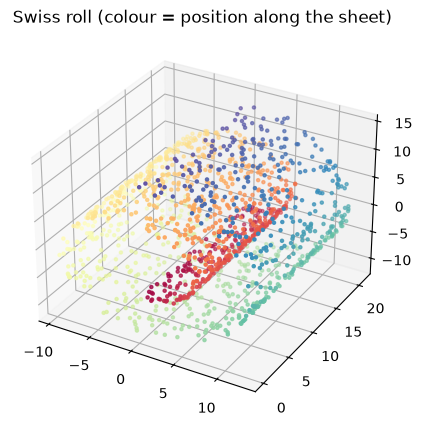

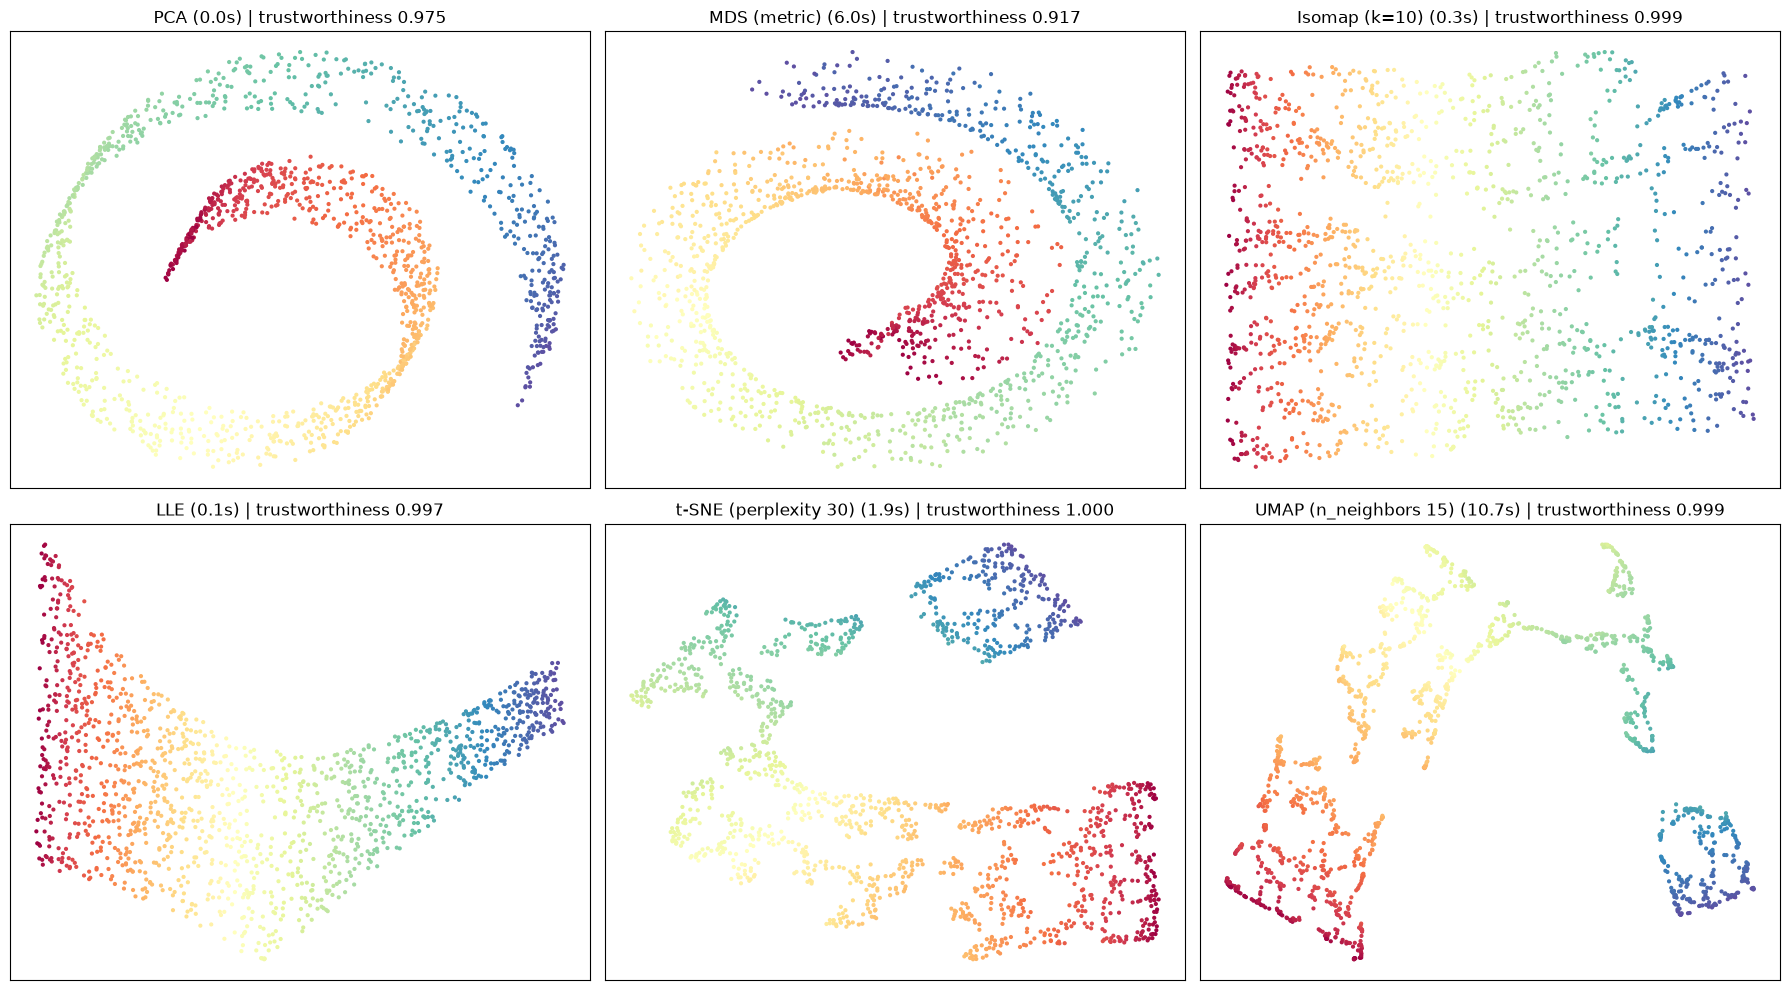

In [2]:
Xs, t = make_swiss_roll(1500, noise=0.05, random_state=0)
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(projection="3d")
ax.scatter(*Xs.T, c=t, cmap="Spectral", s=5); ax.set_title("Swiss roll (colour = position along the sheet)"); plt.show()

methods = {"PCA": PCA(2), "MDS (metric)": MDS(2, random_state=0, n_init=1, init="random"), "Isomap (k=10)": Isomap(n_neighbors=10, n_components=2),
           "LLE": LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=0),
           "t-SNE (perplexity 30)": TSNE(2, perplexity=30, random_state=0), "UMAP (n_neighbors 15)": umap.UMAP(n_neighbors=15, random_state=0)}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, m) in zip(axes.ravel(), methods.items()):
    t0 = time.perf_counter(); E = m.fit_transform(Xs); dt = time.perf_counter() - t0
    ax.scatter(*E.T, c=t, cmap="Spectral", s=4); ax.set_title(f"{name} ({dt:.1f}s) | trustworthiness {trustworthiness(Xs, E, n_neighbors=10):.3f}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

- **PCA / MDS** project the roll flat (layers overlap).
- **Isomap** replaces straight-line distances by **shortest-path distances on a k-NN graph** (geodesics) and unrolls the sheet.
- **t-SNE / UMAP** preserve local neighbourhoods; they may tear the sheet into pieces but keep neighbours together.
- **Trustworthiness** (0-1) measures how many embedded neighbours are true neighbours.

## **2. t-SNE**
1. In high-D, convert distances to probabilities $p_{j|i}\propto\exp(-\lVert x_i-x_j\rVert^2/2\sigma_i^2)$; $\sigma_i$ is set so each point has an effective number of neighbours = **perplexity**.
2. In low-D, use a heavy-tailed **Student-t** kernel $q_{ij}\propto(1+\lVert y_i-y_j\rVert^2)^{-1}$.
3. Move the low-D points to minimise $KL(P\|Q)$ (Day 12) by gradient descent.

### Perplexity matters

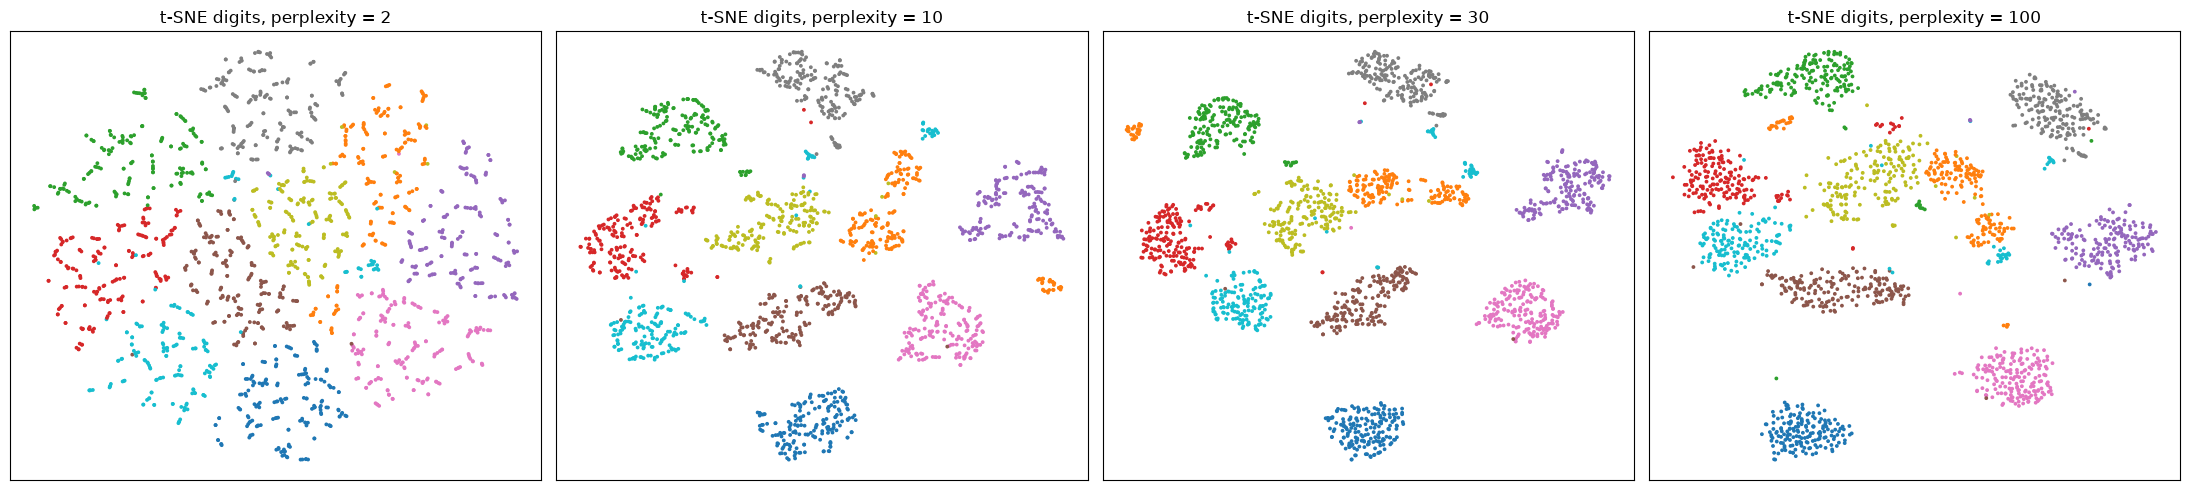

In [3]:
Xd, yd = load_digits(return_X_y=True)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, perp in zip(axes, [2, 10, 30, 100]):
    E = TSNE(2, perplexity=perp, random_state=0).fit_transform(Xd)
    ax.scatter(*E.T, c=yd, cmap="tab10", s=3); ax.set_title(f"t-SNE digits, perplexity = {perp}"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### How to read (and not read) a t-SNE plot (Wattenberg et al., 2016)
- Cluster **sizes** mean nothing (t-SNE expands dense and contracts sparse regions).
- **Distances between clusters** are not reliable.
- Random noise can look like clusters at low perplexity.
- Always try several perplexities and seeds.

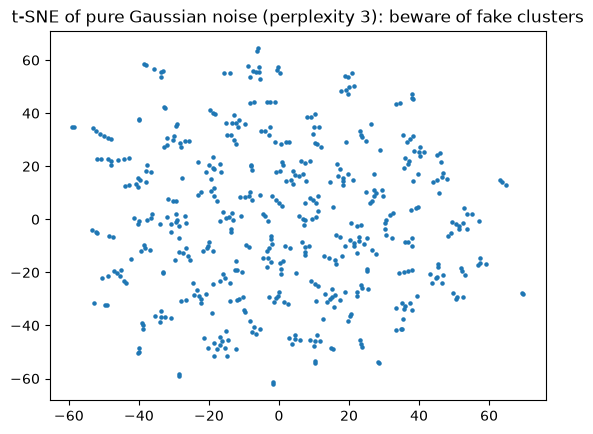

In [4]:
noise = rng.normal(size=(500, 50))
E_noise = TSNE(2, perplexity=3, random_state=0).fit_transform(noise)
plt.scatter(*E_noise.T, s=5); plt.title("t-SNE of pure Gaussian noise (perplexity 3): beware of fake clusters"); plt.show()

## **3. UMAP**
UMAP (McInnes et al., 2018) builds a fuzzy k-NN graph and optimises a low-D layout with a cross-entropy objective. Compared with t-SNE: much **faster**, preserves more **global** structure, has a `transform` for **new data**, and can embed into more than 2 dimensions as preprocessing for clustering. Key parameters: `n_neighbors` (local vs global balance) and `min_dist` (how tightly points pack).

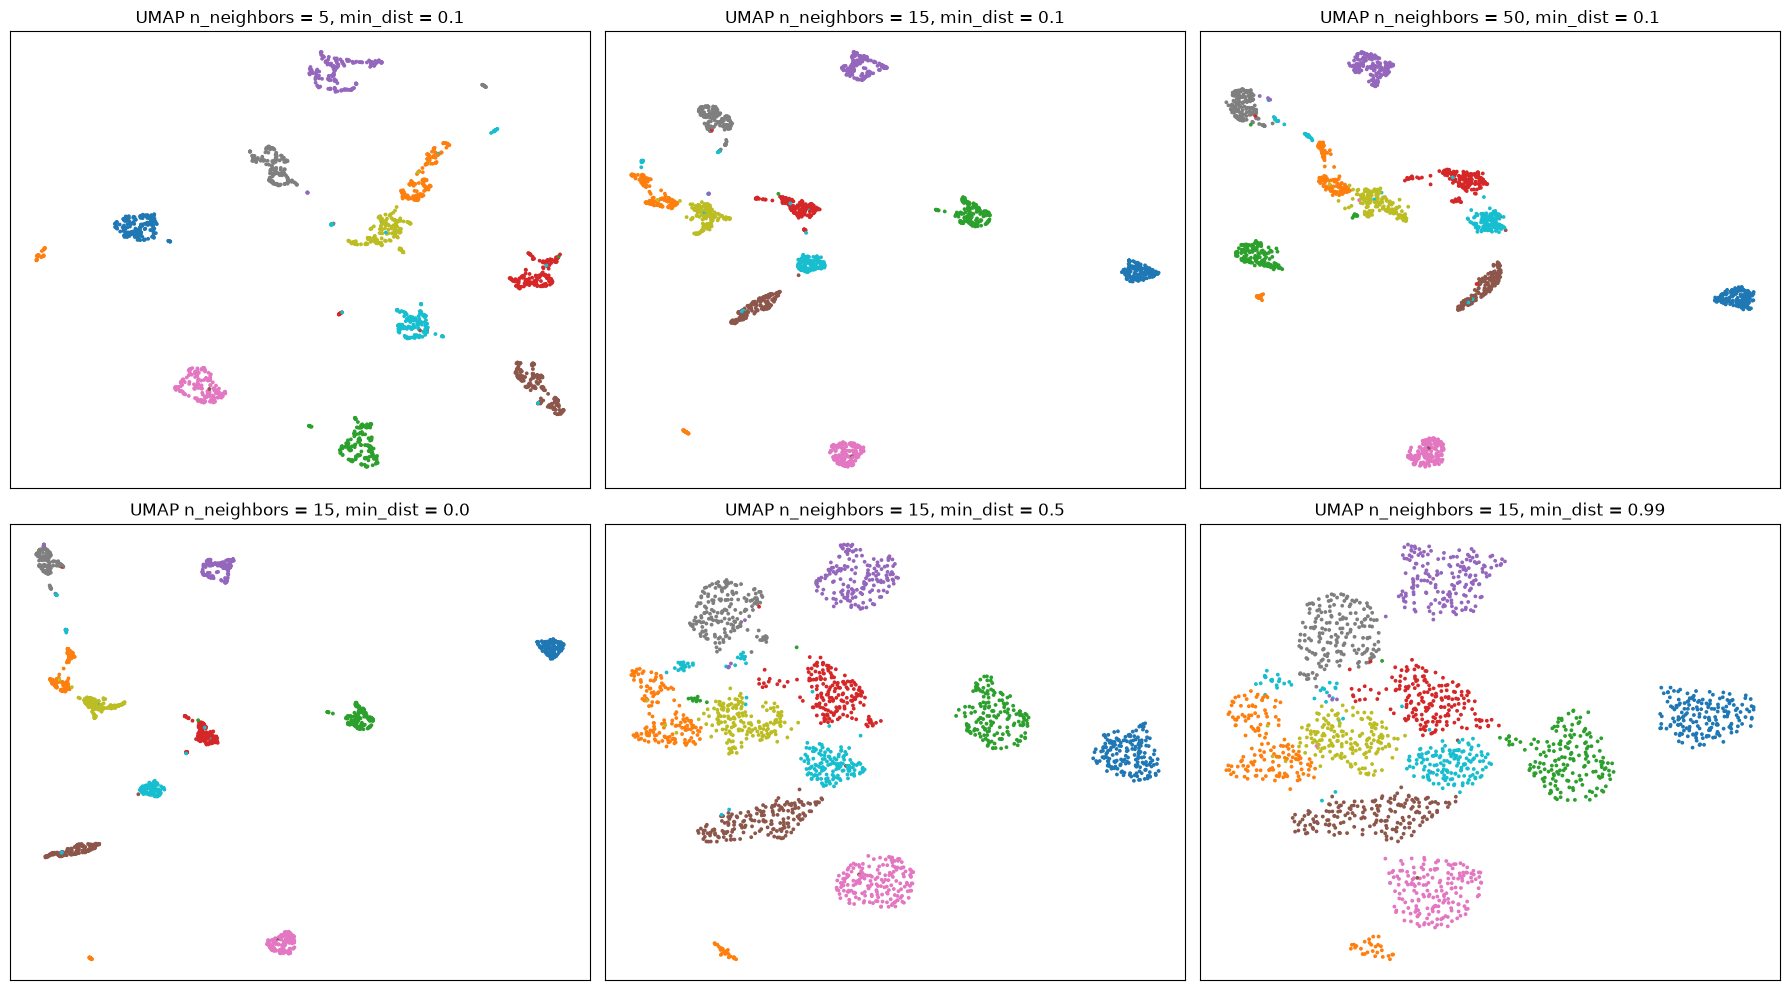

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (nn, md) in zip(axes.ravel(), [(5, 0.1), (15, 0.1), (50, 0.1), (15, 0.0), (15, 0.5), (15, 0.99)]):
    E = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=0).fit_transform(Xd)
    ax.scatter(*E.T, c=yd, cmap="tab10", s=3); ax.set_title(f"UMAP n_neighbors = {nn}, min_dist = {md}"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### Embedding new samples

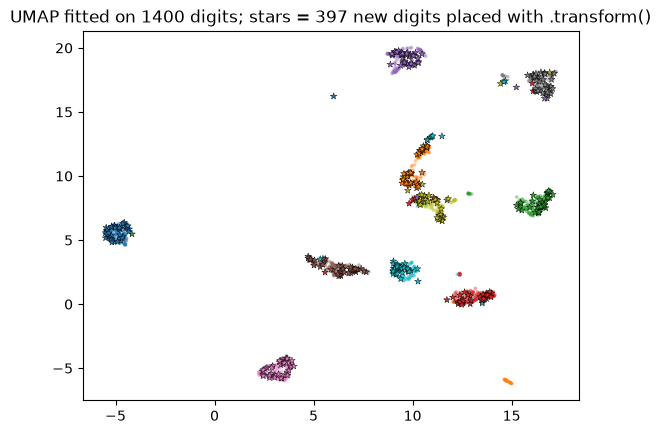

kNN accuracy in the 2-D UMAP space (new digits): 0.947


In [6]:
Xtr_d, Xte_d, ytr_d, yte_d = Xd[:1400], Xd[1400:], yd[:1400], yd[1400:]
reducer = umap.UMAP(n_neighbors=15, random_state=0).fit(Xtr_d)
E_tr, E_te = reducer.embedding_, reducer.transform(Xte_d)
plt.scatter(*E_tr.T, c=ytr_d, cmap="tab10", s=3, alpha=0.3); plt.scatter(*E_te.T, c=yte_d, cmap="tab10", s=25, marker="*", edgecolor="k", lw=0.3)
plt.title("UMAP fitted on 1400 digits; stars = 397 new digits placed with .transform()"); plt.show()
from sklearn.neighbors import KNeighborsClassifier
print("kNN accuracy in the 2-D UMAP space (new digits):", round(KNeighborsClassifier(5).fit(E_tr, ytr_d).score(E_te, yte_d), 3))

## **4. Quantitative Comparison on Digits**

In [7]:
rows = []
for name, m in {"PCA": PCA(2), "Isomap": Isomap(n_neighbors=10), "t-SNE": TSNE(2, random_state=0), "UMAP": umap.UMAP(random_state=0)}.items():
    t0 = time.perf_counter(); E = m.fit_transform(Xd); dt = time.perf_counter() - t0
    from sklearn.model_selection import cross_val_score
    rows.append({"method": name, "seconds": dt, "trustworthiness@10": trustworthiness(Xd, E, n_neighbors=10),
                 "kNN acc in 2-D (CV)": cross_val_score(KNeighborsClassifier(5), E, yd, cv=5).mean()})
pd.DataFrame(rows).set_index("method").round(3)

,seconds,trustworthiness@10,kNN acc in 2-D (CV)
method,,,
PCA,0.002,0.830,0.603
Isomap,0.501,0.838,0.702
t-SNE,2.451,0.993,0.976
UMAP,3.718,0.989,0.981


(The kNN accuracy uses an embedding computed on all data, so it is only a rough indicator of class separation, not an honest classifier estimate.)

# **Part 2: Going Deeper - Pitfalls for Scientific Use**

1. **Visualisation, not analysis**: do not compute distances, densities or cluster statistics in t-SNE space. Run clustering in the original space or a PCA/UMAP space with more dimensions, and use the 2-D plot only to look.
2. **Hyperparameters and seeds** change the picture; report them and show several.
3. **Global structure**: t-SNE initialised with PCA (`init="pca"`, the default) preserves global layout better (Kobak & Linderman, 2021).
4. **Preprocessing**: scale features; for very high-D data, run PCA to ~50 dimensions first (faster, less noise).
5. **Leakage**: an embedding fitted on all data before splitting leaks test information into the features.

### The crowding problem and the Student-t kernel
In 10-D, many points can be equidistant neighbours; in 2-D there is not enough room. A Gaussian kernel in low-D would squash everything into the centre. The heavy-tailed Student-t lets moderately distant points be placed **far away**, opening gaps between clusters.

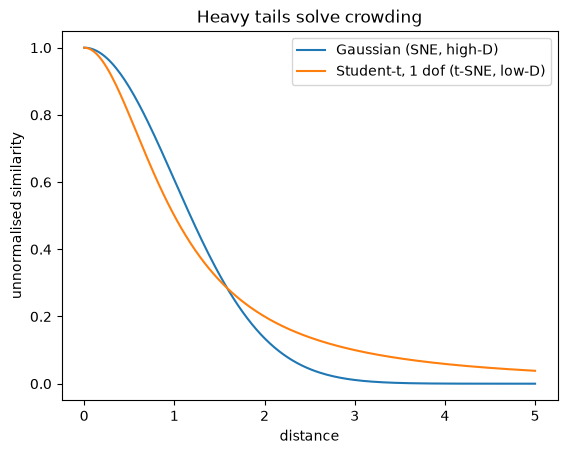

In [8]:
d = np.linspace(0, 5, 200)
plt.plot(d, np.exp(-d ** 2 / 2), label="Gaussian (SNE, high-D)"); plt.plot(d, 1 / (1 + d ** 2), label="Student-t, 1 dof (t-SNE, low-D)")
plt.xlabel("distance"); plt.ylabel("unnormalised similarity"); plt.legend(); plt.title("Heavy tails solve crowding"); plt.show()

## **Practice Problems**
1. Apply PCA to 30 dimensions, then t-SNE, on the digits. Is it faster? Does the picture change?
2. Run t-SNE on the digits with 3 different seeds. Which features of the plot are stable?
3. Use UMAP with `n_components=10` as preprocessing for HDBSCAN on the digits and report the ARI against the true labels.
4. *(Advanced)* Compute trustworthiness at n_neighbors = 5, 30 and 100 for PCA, t-SNE and UMAP. Which method preserves larger-scale structure?

PCA(30) + t-SNE: 2.5s


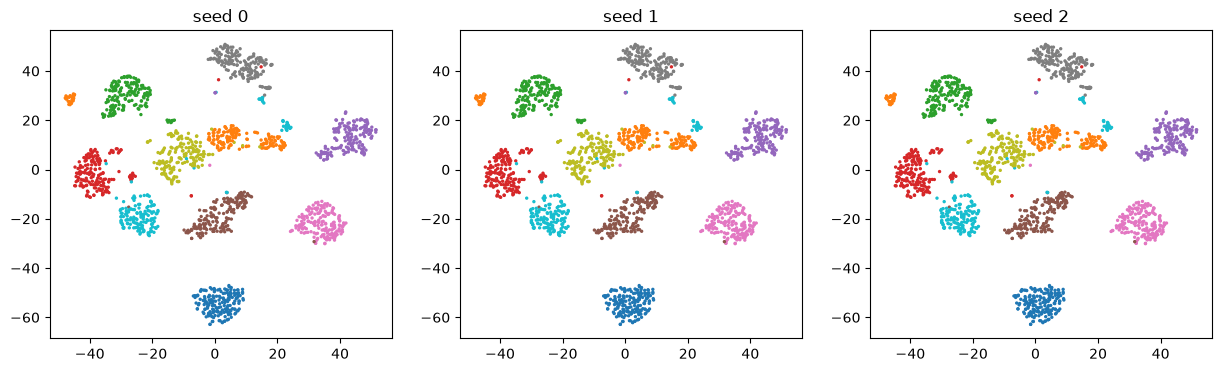

UMAP(10-D) + HDBSCAN: 9 clusters, ARI 0.809, noise 0.2%


       PCA  t-SNE   UMAP
5    0.830  0.995  0.990
30   0.830  0.985  0.983
100  0.835  0.963  0.960


In [9]:
# Solution 1
t0 = time.perf_counter(); E1 = TSNE(2, random_state=0).fit_transform(PCA(30).fit_transform(Xd)); print(f"PCA(30) + t-SNE: {time.perf_counter() - t0:.1f}s")
# Solution 2
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, s in zip(axes, [0, 1, 2]):
    ax.scatter(*TSNE(2, random_state=s).fit_transform(Xd).T, c=yd, cmap="tab10", s=2); ax.set_title(f"seed {s}")
plt.show()
# Solution 3
from sklearn.cluster import HDBSCAN
from sklearn.metrics import adjusted_rand_score
E10 = umap.UMAP(n_components=10, n_neighbors=30, min_dist=0.0, random_state=0).fit_transform(Xd)
lab = HDBSCAN(min_cluster_size=40).fit_predict(E10)
print(f"UMAP(10-D) + HDBSCAN: {len(set(lab) - {-1})} clusters, ARI {adjusted_rand_score(yd, lab):.3f}, noise {np.mean(lab == -1):.1%}")
# Solution 4
embs = {"PCA": PCA(2).fit_transform(Xd), "t-SNE": TSNE(2, random_state=0).fit_transform(Xd), "UMAP": umap.UMAP(random_state=0).fit_transform(Xd)}
print(pd.DataFrame({k: {nn: round(trustworthiness(Xd, E, n_neighbors=nn), 3) for nn in [5, 30, 100]} for k, E in embs.items()}))

## **Key References**
- van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *JMLR*, 9, 2579-2605.
- McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform manifold approximation and projection for dimension reduction. arXiv:1802.03426.
- Tenenbaum, J. B., de Silva, V., & Langford, J. C. (2000). A global geometric framework for nonlinear dimensionality reduction. *Science*, 290(5500), 2319-2323.
- Roweis, S. T., & Saul, L. K. (2000). Nonlinear dimensionality reduction by locally linear embedding. *Science*, 290(5500), 2323-2326.
- Wattenberg, M., Viegas, F., & Johnson, I. (2016). How to use t-SNE effectively. *Distill*. doi:10.23915/distill.00002
- Kobak, D., & Linderman, G. C. (2021). Initialization is critical for preserving global data structure in both t-SNE and UMAP. *Nature Biotechnology*, 39, 156-157.